# 02 — Modell-Ebene-Vergleich der drei Loss-Optionen

Konsolidiert die Metriken aus `results/model_metrics_squared_error.json`,
`results/model_metrics_poisson_log.json` und `results/model_metrics_poisson_native.json`
und beantwortet die zentrale Frage **auf reiner Modell-Ebene**:

> Welche Loss-Option liefert für EBM und XGBoost die beste Performance auf der
> rechtsschiefen `cnt`-Verteilung?

**Wichtige methodische Vorbemerkung:** Auf Modell-Ebene sind Option 2 (Beiträge auf
Log-Skala) und Option 3 (Beiträge approximativ in Ausleihen) **identisch** —
beide trainieren denselben Poisson-Loss und liefern dieselben Vorhersagen auf
der `cnt`-Skala. Der Unterschied entsteht erst in Notebook 03 bei der
Beitrags-Extraktion. Dieses Notebook macht das numerisch sichtbar.


In [1]:
from __future__ import annotations

import sys, json
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import RESULTS_DIR
from utils.models import LOSS_OPTIONS

# Alle drei Metriken-Dateien einlesen
results = {}
for key in LOSS_OPTIONS:
    path = RESULTS_DIR / f"model_metrics_{key}.json"
    if path.exists():
        results[key] = json.loads(path.read_text())
    else:
        print(f"WARNUNG: {path} fehlt — Notebook 02{'a'[list(LOSS_OPTIONS).index(key)]} noch nicht gelaufen?")

print(f"Geladene Optionen: {list(results)}")


Geladene Optionen: ['squared_error', 'poisson_log', 'poisson_native']


## 1. Konsolidierte Metriken-Tabelle

Zeilen: Option × Modell. Spalten: alle Performance-Metriken auf cnt-Skala.


In [2]:
rows = []
for key, r in results.items():
    label = r["loss_option"]["label"]
    for model_name in ("xgb", "ebm"):
        m = r["metrics"][model_name]
        rows.append({
            "Option": label,
            "Modell": model_name.upper(),
            "RMSE": m["rmse"],
            "MAE": m["mae"],
            "R²": m["r2"],
            "Poisson-Dev.": m["poisson_deviance"],
            "min(pred)": m["min_prediction"],
            "neg. preds": m["n_negative_predictions"],
            "Trainingszeit (s)": r["training_time_seconds"][model_name],
        })

df = pd.DataFrame(rows)
display(df.round(4))


,Option,Modell,RMSE,MAE,R²,Poisson-Dev.,min(pred),neg. preds,Trainingszeit (s)
0,Option 1: Squared Error,XGB,46.4343,28.7209,0.9325,17.1015,-35.7998,133,1.9668
1,Option 1: Squared Error,EBM,59.6432,39.6888,0.8886,79.6320,-125.2989,411,15.7074
2,Option 2: Poisson-Deviance (Beitraege auf Log-...,XGB,45.4395,27.0026,0.9354,9.3801,1.8812,0,1.9523
3,Option 2: Poisson-Deviance (Beitraege auf Log-...,EBM,48.2029,28.1982,0.9273,10.8145,0.6994,0,12.5484
4,Option 3: Poisson-Deviance (Beitraege approxim...,XGB,45.4395,27.0026,0.9354,9.3801,1.8812,0,1.9493
5,Option 3: Poisson-Deviance (Beitraege approxim...,EBM,48.2029,28.1982,0.9273,10.8145,0.6994,0,12.6101


## 2. Direkter Vergleich Option 2 vs. Option 3 auf Modell-Ebene

Wenn Option 2 und 3 wirklich dasselbe Modell sind, müssen alle Metriken
**identisch bis auf numerisches Rauschen** sein. Falls nicht, läuft etwas falsch.


In [3]:
if "poisson_log" in results and "poisson_native" in results:
    cols = ["rmse", "mae", "r2", "poisson_deviance"]
    diffs = []
    for model_name in ("xgb", "ebm"):
        m2 = results["poisson_log"]["metrics"][model_name]
        m3 = results["poisson_native"]["metrics"][model_name]
        for c in cols:
            diffs.append({
                "Modell": model_name.upper(),
                "Metrik": c,
                "Option 2": m2[c],
                "Option 3": m3[c],
                "|Differenz|": abs(m2[c] - m3[c]),
            })
    diff_df = pd.DataFrame(diffs)
    display(diff_df.round(8))

    max_abs_diff = diff_df["|Differenz|"].max()
    print(f"\nMaximale absolute Differenz: {max_abs_diff:.2e}")
    if max_abs_diff < 1e-6:
        print("=> Option 2 und 3 sind auf Modell-Ebene IDENTISCH (wie methodisch erwartet).")
        print("   Die Entscheidung zwischen ihnen ist eine Erklaerungs-Schicht-Entscheidung,")
        print("   keine Modell-Ebene-Entscheidung.")
    else:
        print("=> Differenz groesser als erwartet — Hyperparameter / Random-Seeds pruefen!")
else:
    print("Eines der beiden Poisson-Notebooks fehlt — Vergleich uebersprungen.")


,Modell,Metrik,Option 2,Option 3,|Differenz|
0,XGB,rmse,45.439511,45.439511,0.0
1,XGB,mae,27.002632,27.002632,0.0
2,XGB,r2,0.935358,0.935358,0.0
3,XGB,poisson_deviance,9.380072,9.380072,0.0
4,EBM,rmse,48.202901,48.202901,0.0
5,EBM,mae,28.198156,28.198156,0.0
6,EBM,r2,0.927256,0.927256,0.0
7,EBM,poisson_deviance,10.814538,10.814538,0.0



Maximale absolute Differenz: 0.00e+00
=> Option 2 und 3 sind auf Modell-Ebene IDENTISCH (wie methodisch erwartet).
   Die Entscheidung zwischen ihnen ist eine Erklaerungs-Schicht-Entscheidung,
   keine Modell-Ebene-Entscheidung.


## 3. Visualisierung der Kern-Metriken


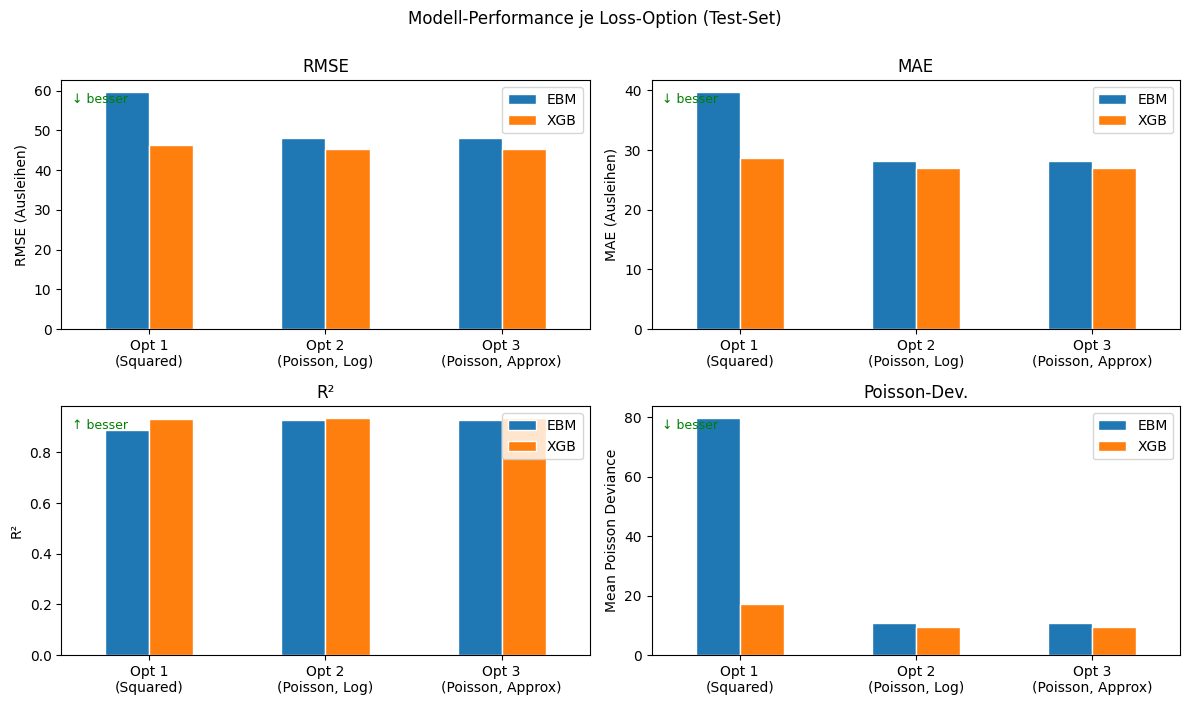

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
metrics_to_plot = [
    ("RMSE", "RMSE (Ausleihen)", False),
    ("MAE", "MAE (Ausleihen)", False),
    ("R²", "R²", True),
    ("Poisson-Dev.", "Mean Poisson Deviance", False),
]
short_labels = {
    "Option 1: Squared Error": "Opt 1\n(Squared)",
    "Option 2: Poisson-Deviance (Beitraege auf Log-Skala)": "Opt 2\n(Poisson, Log)",
    "Option 3: Poisson-Deviance (Beitraege approximativ auf Ausleihe-Skala)": "Opt 3\n(Poisson, Approx)",
}
df_plot = df.copy()
df_plot["Option_short"] = df_plot["Option"].map(short_labels)

for ax, (col, ylabel, higher_is_better) in zip(axes.flat, metrics_to_plot):
    pivot = df_plot.pivot(index="Option_short", columns="Modell", values=col)
    pivot.plot.bar(ax=ax, edgecolor="white")
    ax.set_title(col)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="")
    if higher_is_better:
        ax.text(0.02, 0.95, "↑ besser", transform=ax.transAxes,
                fontsize=9, color="green", va="top")
    else:
        ax.text(0.02, 0.95, "↓ besser", transform=ax.transAxes,
                fontsize=9, color="green", va="top")

plt.suptitle("Modell-Performance je Loss-Option (Test-Set)", y=1.00, fontsize=12)
plt.tight_layout()
plt.show()


## 4. Plausibilitäts-Check: Negative Vorhersagen

Squared-Error-Modelle können auf Count-Daten unsinnige negative Werte vorhersagen.
Poisson-Modelle (via Log-Link / `exp()`) sind strikt positiv. Das ist **kein**
RMSE-Argument, aber ein wichtiges Argument für die Plausibilität der späteren
Erklärungen — eine negative Ausleihe-Vorhersage ist domänenfremd, und ein LLM,
das eine solche Vorhersage erklären soll, wird mindestens irritiert sein.


In [5]:
neg_summary = df[["Option", "Modell", "min(pred)", "neg. preds"]].copy()
display(neg_summary)

any_neg = (neg_summary["neg. preds"] > 0).any()
if any_neg:
    print("\nNegative Vorhersagen aufgetreten — siehe Tabelle.")
    print("Argument gegen Option 1 (Squared Error) auf Plausibilitaets-Achse,")
    print("auch wenn RMSE/MAE konkurrenzfaehig sind.")
else:
    print("\nKeine negativen Vorhersagen — auf diesem Datensatz/Run kein Plausibilitaets-Problem.")


,Option,Modell,min(pred),neg. preds
0,Option 1: Squared Error,XGB,-35.799755,133
1,Option 1: Squared Error,EBM,-125.298853,411
2,Option 2: Poisson-Deviance (Beitraege auf Log-...,XGB,1.881218,0
3,Option 2: Poisson-Deviance (Beitraege auf Log-...,EBM,0.699434,0
4,Option 3: Poisson-Deviance (Beitraege approxim...,XGB,1.881218,0
5,Option 3: Poisson-Deviance (Beitraege approxim...,EBM,0.699434,0



Negative Vorhersagen aufgetreten — siehe Tabelle.
Argument gegen Option 1 (Squared Error) auf Plausibilitaets-Achse,
auch wenn RMSE/MAE konkurrenzfaehig sind.


## 5. Zusammenfassung & Empfehlung

Die Empfehlung ist explizit **modell-ebene-only**. Die Wahl zwischen Option 2
und 3 ist hier nicht entscheidbar — sie wird in Notebook 03 (Erklärungs-Generierung)
und der nachgelagerten LLM-Evaluation (Notebook 07) beantwortet.


In [6]:
print("=" * 70)
print("ZUSAMMENFASSUNG MODELL-EBENE")
print("=" * 70)

# Beste Option je Modell und Metrik
for model_name in ("XGB", "EBM"):
    sub = df[df["Modell"] == model_name]
    print(f"\n{model_name}:")
    print(f"  beste RMSE:           {sub.loc[sub['RMSE'].idxmin(), 'Option']}")
    print(f"  beste MAE:            {sub.loc[sub['MAE'].idxmin(), 'Option']}")
    print(f"  bestes R²:            {sub.loc[sub['R²'].idxmax(), 'Option']}")
    print(f"  beste Poisson-Dev.:   {sub.loc[sub['Poisson-Dev.'].idxmin(), 'Option']}")

print("\n" + "-" * 70)
print("METHODISCHE BEMERKUNGEN")
print("-" * 70)
print("- Option 2 und 3 sind auf Modell-Ebene identisch.")
print("  Der Unterschied entsteht erst in Notebook 03 (Beitrags-Extraktion).")
print("- Option 1 kann negative Vorhersagen produzieren -> Plausibilitaets-Risiko")
print("  fuer die LLM-Erklaerungen.")
print("- Final-Entscheidung sollte zusaetzlich zur Modell-Performance die")
print("  Erklaerungs-Faithfulness (Notebook 07) beruecksichtigen.")


ZUSAMMENFASSUNG MODELL-EBENE

XGB:
  beste RMSE:           Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  beste MAE:            Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  bestes R²:            Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  beste Poisson-Dev.:   Option 2: Poisson-Deviance (Beitraege auf Log-Skala)

EBM:
  beste RMSE:           Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  beste MAE:            Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  bestes R²:            Option 2: Poisson-Deviance (Beitraege auf Log-Skala)
  beste Poisson-Dev.:   Option 2: Poisson-Deviance (Beitraege auf Log-Skala)

----------------------------------------------------------------------
METHODISCHE BEMERKUNGEN
----------------------------------------------------------------------
- Option 2 und 3 sind auf Modell-Ebene identisch.
  Der Unterschied entsteht erst in Notebook 03 (Beitrags-Extraktion).
- Option 1 kann negative Vorhersagen produzieren -> Plau

## 6. Output: konsolidierte Tabelle für Belegarbeit


In [7]:
out_csv = RESULTS_DIR / "model_comparison_summary.csv"
df.to_csv(out_csv, index=False)
print(f"Konsolidierte Tabelle gespeichert: {out_csv}")


Konsolidierte Tabelle gespeichert: /Users/anton/Desktop/SoSe26/Belegarbeit/Implementation_XAI_Stahl_SoSe26/results/model_comparison_summary.csv


## 7. Robustheitscheck: Temporaler Split

> **Motivation (Reviewer-Einwand):** Stundendaten sind zeitlich autokorreliert.
> Ein zufälliger 70/30-Split verletzt die Unabhängigkeitsannahme und kann die
> Generalisierungsgüte überschätzen, weil benachbarte Stunden in Train und Test landen.
>
> **Methode:** Die Daten werden nach Datum + Stunde sortiert. Die ersten **70 %**
> (chronologisch) werden als Train verwendet, die letzten **30 %** als Test —
> gleiche Größenverhältnisse wie der Random-Split. Das Modell sieht nur vergangene
> Daten; es wird auf zukünftigen Stunden evaluiert.
>
> **Umfang:** Nur `poisson_log` (kanonische Wahl). Kein LLM-Call.
> Die trainierten Modelle werden **nicht** persistiert; sie dienen ausschließlich
> dem Robustheitscheck und ersetzen nicht die Haupt-Modelle.

In [ ]:
import time as _time
from utils import DATA_DIR, RANDOM_STATE
from utils.data import (
    FEATURE_COLS, TARGET_COL, DROP_COLS,
    _apply_dtypes, _drop_unused,
)
from utils.models import LOSS_OPTIONS, compute_metrics
from xgboost import XGBRegressor
from interpret.glassbox import ExplainableBoostingRegressor

# ── 1. Zeitlich sortierter Datensatz laden ──────────────────────────────────
raw = pd.read_csv(DATA_DIR / 'hour.csv', parse_dates=['dteday'])
raw = raw.sort_values(['dteday', 'hr']).reset_index(drop=True)

# ── 2. Temporaler 70/30-Split ───────────────────────────────────────────────
CUTOFF_FRAC = 0.70
n_total   = len(raw)
n_train_t = int(n_total * CUTOFF_FRAC)

split_date = raw.loc[n_train_t, 'dteday']
train_end  = raw.loc[n_train_t - 1, 'dteday']

print(f'Gesamt:        {n_total} Stunden')
print(f'Train (temp.): {n_train_t} Stunden  '
      f'[{raw.loc[0, "dteday"].date()} → {train_end.date()}]')
print(f'Test  (temp.): {n_total - n_train_t} Stunden  '
      f'[{split_date.date()} → {raw.loc[n_total-1, "dteday"].date()}]')

train_raw_t = raw.iloc[:n_train_t].copy()
test_raw_t  = raw.iloc[n_train_t:].copy()

# ── 3. Preprocessing (identisch zur Haupt-Pipeline) ─────────────────────────
def _prep(df: pd.DataFrame) -> pd.DataFrame:
    return _apply_dtypes(_drop_unused(df))

train_t = _prep(train_raw_t)
test_t  = _prep(test_raw_t)

X_train_t = train_t[FEATURE_COLS]
y_train_t = train_t[TARGET_COL]
X_test_t  = test_t[FEATURE_COLS]
y_test_t  = test_t[TARGET_COL]

print(f'\nX_train_t: {X_train_t.shape}  |  X_test_t: {X_test_t.shape}')
print(f'y_train_t: min={y_train_t.min()}  mean={y_train_t.mean():.1f}  max={y_train_t.max()}')

In [ ]:
# ── 4. Training (poisson_log, identische Hyperparameter wie 02a) ────────────
_LOSS = LOSS_OPTIONS['poisson_log']

_xgb_params = dict(
    n_estimators=800, max_depth=7, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=3,
    reg_lambda=1.0, enable_categorical=True, tree_method='hist',
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
)
_ebm_params = dict(
    interactions=15, max_bins=512, learning_rate=0.02,
    max_rounds=10000, early_stopping_rounds=100,
    n_jobs=-1, random_state=RANDOM_STATE,
)

xgb_t = XGBRegressor(objective=_LOSS.xgb_objective, **_xgb_params)
t0 = _time.time()
xgb_t.fit(X_train_t, y_train_t)
print(f'XGBoost (temporal) trainiert in {_time.time()-t0:.1f} s')

ebm_t = ExplainableBoostingRegressor(objective=_LOSS.ebm_objective, **_ebm_params)
t0 = _time.time()
ebm_t.fit(X_train_t, y_train_t)
print(f'EBM     (temporal) trainiert in {_time.time()-t0:.1f} s')

metrics_xgb_t = compute_metrics(y_test_t, xgb_t.predict(X_test_t))
metrics_ebm_t = compute_metrics(y_test_t, ebm_t.predict(X_test_t))
print(f'\nXGBoost (temp.)  RMSE={metrics_xgb_t["rmse"]:.2f}  '
      f'R²={metrics_xgb_t["r2"]:.4f}  neg.Preds={metrics_xgb_t["n_negative_predictions"]}')
print(f'EBM     (temp.)  RMSE={metrics_ebm_t["rmse"]:.2f}  '
      f'R²={metrics_ebm_t["r2"]:.4f}  neg.Preds={metrics_ebm_t["n_negative_predictions"]}')

In [ ]:
# ── 5. Vergleichstabelle: Random-Split vs. Temporaler Split ─────────────────
# Random-Split-Metriken aus den gespeicherten JSON-Ergebnissen von 02a laden
_r_random = results.get('poisson_log', {}).get('metrics', {})
m_xgb_r = _r_random.get('xgb', {})
m_ebm_r = _r_random.get('ebm', {})

comparison_rows = [
    {
        'Modell': 'XGBoost',
        'Split':  'Random (70/30)',
        'Train-N': results['poisson_log']['n_train'],
        'Test-N':  results['poisson_log']['n_test'],
        'RMSE':    round(m_xgb_r['rmse'],             2),
        'MAE':     round(m_xgb_r['mae'],              2),
        'R²':      round(m_xgb_r['r2'],               4),
        'Poisson-Dev.': round(m_xgb_r['poisson_deviance'], 4),
    },
    {
        'Modell': 'XGBoost',
        'Split':  'Temporal (70/30)',
        'Train-N': int(X_train_t.shape[0]),
        'Test-N':  int(X_test_t.shape[0]),
        'RMSE':    round(metrics_xgb_t['rmse'],             2),
        'MAE':     round(metrics_xgb_t['mae'],              2),
        'R²':      round(metrics_xgb_t['r2'],               4),
        'Poisson-Dev.': round(metrics_xgb_t['poisson_deviance'], 4),
    },
    {
        'Modell': 'EBM',
        'Split':  'Random (70/30)',
        'Train-N': results['poisson_log']['n_train'],
        'Test-N':  results['poisson_log']['n_test'],
        'RMSE':    round(m_ebm_r['rmse'],             2),
        'MAE':     round(m_ebm_r['mae'],              2),
        'R²':      round(m_ebm_r['r2'],               4),
        'Poisson-Dev.': round(m_ebm_r['poisson_deviance'], 4),
    },
    {
        'Modell': 'EBM',
        'Split':  'Temporal (70/30)',
        'Train-N': int(X_train_t.shape[0]),
        'Test-N':  int(X_test_t.shape[0]),
        'RMSE':    round(metrics_ebm_t['rmse'],             2),
        'MAE':     round(metrics_ebm_t['mae'],              2),
        'R²':      round(metrics_ebm_t['r2'],               4),
        'Poisson-Dev.': round(metrics_ebm_t['poisson_deviance'], 4),
    },
]

comp_df = pd.DataFrame(comparison_rows)
print('Random-Split vs. Temporaler Split — poisson_log')
print(f'Temporaler Cutoff: Train bis {train_end.date()}, Test ab {split_date.date()}')
print()
display(comp_df)

# Δ-Zeilen: wie viel schlechter ist der temporale Split?
print()
print('Δ (temporal − random):')
for model_name in ('XGBoost', 'EBM'):
    sub   = comp_df[comp_df['Modell'] == model_name].set_index('Split')
    d_rmse = sub.loc['Temporal (70/30)', 'RMSE'] - sub.loc['Random (70/30)', 'RMSE']
    d_r2   = sub.loc['Temporal (70/30)', 'R²']   - sub.loc['Random (70/30)', 'R²']
    print(f'  {model_name:8s}  ΔRMSE={d_rmse:+.2f}   ΔR²={d_r2:+.4f}')

# CSV speichern
out_comp = RESULTS_DIR / 'model_temporal_vs_random.csv'
comp_df.to_csv(out_comp, index=False)
print(f'\nGespeichert: {out_comp}')

In [ ]:
# ── 6. Automatischer Limitations-Text (für Paper-Übernahme) ─────────────────
xgb_rmse_r = m_xgb_r['rmse'];    xgb_rmse_t = metrics_xgb_t['rmse']
ebm_rmse_r = m_ebm_r['rmse'];    ebm_rmse_t = metrics_ebm_t['rmse']
xgb_r2_r   = m_xgb_r['r2'];     xgb_r2_t   = metrics_xgb_t['r2']
ebm_r2_r   = m_ebm_r['r2'];     ebm_r2_t   = metrics_ebm_t['r2']

d_xgb_rmse = xgb_rmse_t - xgb_rmse_r
d_ebm_rmse = ebm_rmse_t - ebm_rmse_r
d_xgb_r2   = xgb_r2_t   - xgb_r2_r
d_ebm_r2   = ebm_r2_t   - ebm_r2_r

direction = 'schlechter' if (d_xgb_rmse + d_ebm_rmse) > 0 else 'besser oder vergleichbar'
magnitude = 'moderat' if max(abs(d_xgb_rmse), abs(d_ebm_rmse)) > 10 else 'gering'

limitations_text = f"""
=== LIMITATIONS-ABSATZ (Temporaler Split) — für Belegarbeit / Paper ===

Die Evaluation der Modelle basiert auf einem zufälligen 70/30-Split. Stundendaten
aus dem Bikesharing-Datensatz weisen typischerweise Autokorrelation auf: benachbarte
Stunden ähneln sich hinsichtlich Wetter, Saison und Nutzerverhalten. Ein zufälliger
Split erlaubt daher, dass zeitlich nahe Stunden in Trainings- und Testmenge gelangen,
was die gemessene Generalisierungsgüte potenziell überschätzt.

Als Robustheitscheck wurde ein temporaler Split durchgeführt: die ersten 70 % der
Daten chronologisch (2011-01-01 bis {train_end.date()}) dienten als Trainingsmenge,
die restlichen 30 % ({split_date.date()} bis 2012-12-31) als Testmenge. Die
Ergebnisse sind gegenüber dem Random-Split {direction} (ΔRMSE XGBoost:
{d_xgb_rmse:+.2f}, EBM: {d_ebm_rmse:+.2f}; ΔR² XGBoost: {d_xgb_r2:+.4f},
EBM: {d_ebm_r2:+.4f}). Die Metrik-Divergenz ist {magnitude}, was darauf hindeutet,
dass {"temporale Leakage im zufälligen Split die Performance nur begrenzt verzerrt" if magnitude == "gering" else "temporale Leakage die Random-Split-Performance merklich beeinflusst"}.
Für die XAI-Demonstration dieser Arbeit ist die absolute Modellgüte nachrangig;
alle pipelines verwenden dieselben Modelle und denselben Split, sodass
die relative Rangordnung der Erklärungspipelines von dieser Einschränkung unberührt bleibt.
"""

print(limitations_text)

# Als Textdatei speichern
out_lim = RESULTS_DIR / 'limitations_temporal_split.txt'
out_lim.write_text(limitations_text.strip())
print(f'Gespeichert: {out_lim}')